In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.optimize import brentq

In [2]:
a = 0.1
b = 0.9
u_star = a + b
v_star = b / ((a+b)**2)
L, N, D = 1, 200, 100
gamma = 1000

In [3]:
def M_matrix(k, gamma, u, v, D):
    j11 = (2* gamma * u * v) - (k**2) - gamma
    j12 = gamma * u**2
    j21 = -(2*gamma*u*v)
    j22 = -(gamma * u**2) - (k**2 * D)
    return np.array([[j11, j12],
                     [j21, j22]])

In [4]:
J = M_matrix(0, gamma= gamma, u=u_star, v=v_star, D=D)

In [5]:
tr_M = np.trace(J)
det_M = np.linalg.det(J)

print(f"turing conditions for reaction-diffusion")
print(f"trace(M) is negative:  {tr_M:.4f} < 0")
print(f"det(M) is positive: {det_M:.4f} > 0")


turing conditions for reaction-diffusion
trace(M) is negative:  -200.0000 < 0
det(M) is positive: 1000000.0000 > 0


In [6]:
def growth_numerical(k, gamma, u, v, D):
    M = M_matrix(k=k, gamma=gamma, u=u, v=v, D=D)
    eigs = np.linalg.eigvals(M)
    return np.max(eigs.real)

In [7]:
def growth_analytical(k, gamma, u, v, D):
    M = M_matrix(k=k, gamma=gamma, u=u, v=v, D=D)
    tr_M = np.trace(M)
    det_M = np.linalg.det(M)
    disc =  (tr_M**2) - (4 * det_M)
    return np.real((tr_M + np.emath.sqrt(disc))/2)

In [8]:
counter = []

for k in np.linspace(0, 30, 100):
    num = growth_numerical(k, gamma=gamma, u=u_star, v=v_star, D=D)
    ana = growth_analytical(k, gamma=gamma, u=u_star, v=v_star, D=D)

    counter.append(np.isclose(ana, num, rtol=1e-5))

print(rf"Matching points: {sum(counter)} / 100")

Matching points: 100 / 100


In [9]:
def det_coeff(gamma, u, v, D):
    A = D
    B = gamma*((u**2) + D - (2*D*u*v))
    C = (gamma**2) * (u**2)
    return A, B, C

In [10]:
def determinant(D, gamma, u, v):
    A, B, C = det_coeff(gamma, u, v, D)
    return ((B**2) - (4*A*C))

In [11]:
def critical_D(a, b, gamma):
    u = a + b
    v = b / ((a+b)**2)

    if ((2*u*v)-1) <= 0:
            return np.nan, u, v, np.nan
    D_lo = gamma*(u**2) / ((gamma*2*u*v)-gamma)
    D_hi = D_lo * 1e2

    if np.trace(M_matrix(0, gamma= gamma, u=u, v=v, D=D)) >= 0:
        return np.nan, u, v, np.nan 

    f_lo = determinant (D_lo,gamma, u, v)
    f_hi = determinant (D_hi,gamma, u, v)
    if f_hi * f_lo > 0:
         return np.nan, u, v, np.nan
    
    D_c = brentq(determinant, D_lo, D_hi, args=(gamma, u, v))

    _, B_c, _ = det_coeff(gamma, u, v, D_c)
    if B_c >= 0:
        return np.nan, u, v, np.nan

    return D_c ,u, v, B_c

''' 
if np.isnan(D_c):
        print("No valid critical D_c found in the given range.")
    else:
        print(f"Verified Critical D_c: {D_c:.4f} (B_c = {B_c:.2f})")
'''

' \nif np.isnan(D_c):\n        print("No valid critical D_c found in the given range.")\n    else:\n        print(f"Verified Critical D_c: {D_c:.4f} (B_c = {B_c:.2f})")\n'

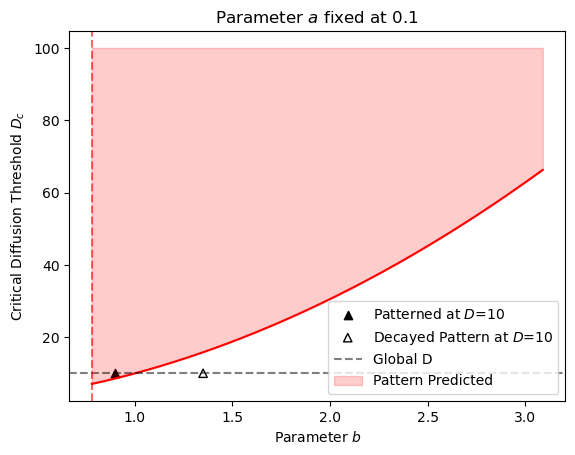

In [29]:
b_succ, Dc_succ = [], []
a_fixed = 0.1
b_list = np.arange(a_fixed * 1.1, a_fixed + 3, 0.01)
gamma_crit_D = 1000

for b in b_list:
    D_c ,_, _, _ = critical_D(a_fixed, b, gamma_crit_D)
    if not np.isnan(D_c):
        b_succ.append(b)
        Dc_succ.append(D_c)

y_top = D

plt.plot(b_succ, Dc_succ, ls='-', color="red")
plt.scatter(0.9, 10, marker="^", color="black", label= rf'Patterned at $D$=10')
plt.scatter(1.35, 10, marker="^", color="black", facecolor= 'none', label=rf'Decayed Pattern at $D$=10')
plt.xlabel("Parameter $b$")
plt.ylabel(rf"Critical Diffusion Threshold $D_c$")
plt.axhline(10, ls='--', alpha =0.5, c='black', label='Global D')
plt.axvline(b_succ[0], ls='--', alpha = 0.6, c='red')
plt.title(rf'Parameter $a$ fixed at 0.1')
plt.fill_between(b_succ, Dc_succ, y_top, color='red', alpha=0.2, label='Pattern Predicted')
plt.legend(loc='lower right')
plt.show()

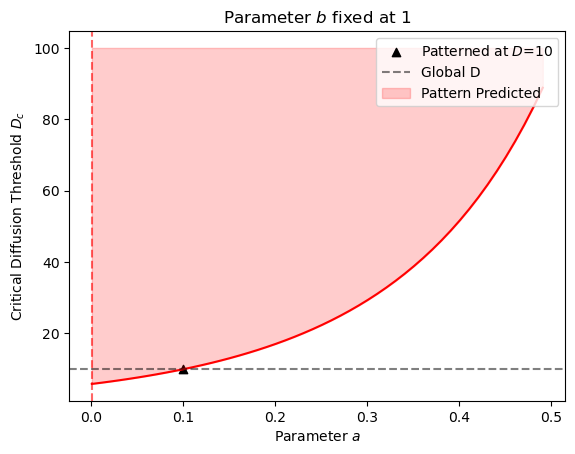

In [28]:
a_succ, Dc_succ = [], []
b_fixed = 1
a_list = np.arange(a_fixed * 0.01, b_fixed * 0.5, 0.01)

for a in a_list:
    D_c ,_, _, _ = critical_D(a, b_fixed, gamma_crit_D)
    if not np.isnan(D_c):
        a_succ.append(a)
        Dc_succ.append(D_c)

plt.plot(a_succ, Dc_succ, ls='-', color="red")
plt.scatter(0.1, 10, marker="^", color="black", label= rf'Patterned at $D$=10')
plt.xlabel("Parameter $a$")
plt.ylabel(rf"Critical Diffusion Threshold $D_c$")
plt.axhline(10, ls='--', alpha =0.5, c='black', label='Global D')
plt.axvline(a_succ[0], ls='--', alpha = 0.6, c='red')
plt.title(rf'Parameter $b$ fixed at 1')
plt.fill_between(a_succ, Dc_succ, y_top, color='red', alpha=0.2, label='Pattern Predicted')
plt.legend(loc='upper right')
plt.show()

0.0993574297188755 0.902008032128514 8.561955150483854


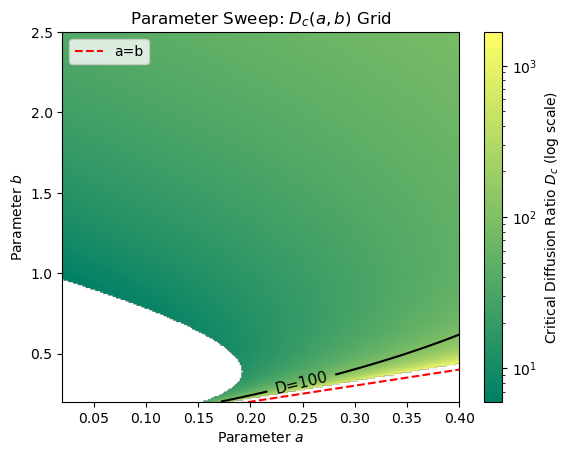

In [30]:
a_vals = np.linspace(0.02, 0.4, 250)
b_vals = np.linspace(0.2, 2.5, 250)
Dc_grid = np.full((len(b_vals), len(a_vals)), np.nan)

for i, b in enumerate(b_vals):
    for j, a in enumerate(a_vals):
        D_c ,_, _, _ = critical_D(a, b, gamma_crit_D)
        Dc_grid[i, j] = D_c

im = plt.imshow(
    Dc_grid,
    cmap='summer',origin="lower",
    aspect='auto',extent=[a_vals[0],a_vals[-1],b_vals[0],b_vals[-1]],
    norm=LogNorm(vmin=np.nanmin(Dc_grid), vmax=np.nanmax(Dc_grid)),
)
plt.plot(a_vals, a_vals, ls="--", c="red", label="a=b")
plt.ylabel(r"Parameter $b$")
plt.xlabel(r"Parameter $a$")
plt.ylim(b_vals[0], b_vals[-1])
plt.colorbar(im, label=r"Critical Diffusion Ratio $D_c$ (log scale)")
plt.title(r"Parameter Sweep: $D_c (a, b)$ Grid")
plt.legend(loc="upper left")

c = plt.contour(
    a_vals, b_vals, 
    Dc_grid, 
    levels=[D], 
    colors="black",
    linewidths=1.5,
    )
fmt = rf'D={D}'
plt.clabel(
    c,
    inline=True,
    fmt=fmt,
    fontsize=11,
    colors="black",
    inline_spacing=8,
)

i = np.argmin(np.abs(b_vals - 0.9))
j = np.argmin(np.abs(a_vals - 0.1))
print(a_vals[j], b_vals[i], Dc_grid[i, j])

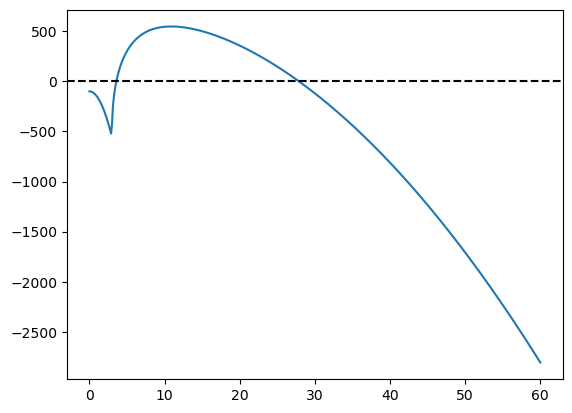

In [15]:
k = np.linspace(0, 60, 500)
lam = np.array([growth_numerical(ki, gamma= gamma, u=u_star, v=v_star, D=D) for ki in k])
plt.plot(k,lam)
plt.axhline(0, c='black', ls= '--')
plt.show()

In [16]:
peak = k[np.argmax(lam)] # k_critical

In [17]:
z = gamma*(((2*D*v_star*u_star) - (u_star**2) - D) / (2*D)) # k^2_critical

In [18]:
print(f"Numerical k peak:   {peak:.4f}")
print(f"Analytical k peak:  {np.sqrt(z):.4f}")
print(f"Absolute Difference: {abs(peak - np.sqrt(z)):.4f}")

Numerical k peak:   10.9419
Analytical k peak:  19.8746
Absolute Difference: 8.9327


In [19]:
n = np.arange(1,20)
k_n = (n * np.pi) / L

In [20]:
lam_n = np.array([
    growth_analytical(k, gamma= gamma, u=u_star, v=v_star, D=20) for k in k_n
    ])

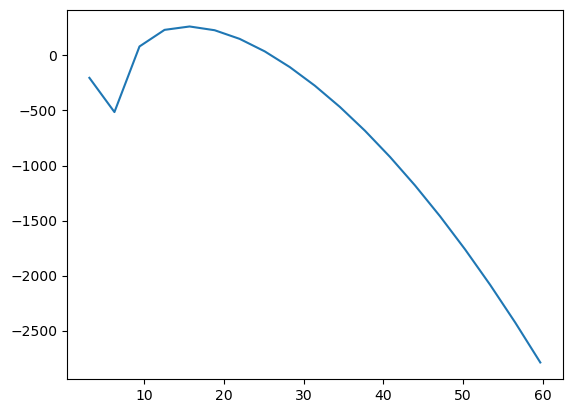

In [21]:
plt.plot(k_n, lam_n)
plt.show()

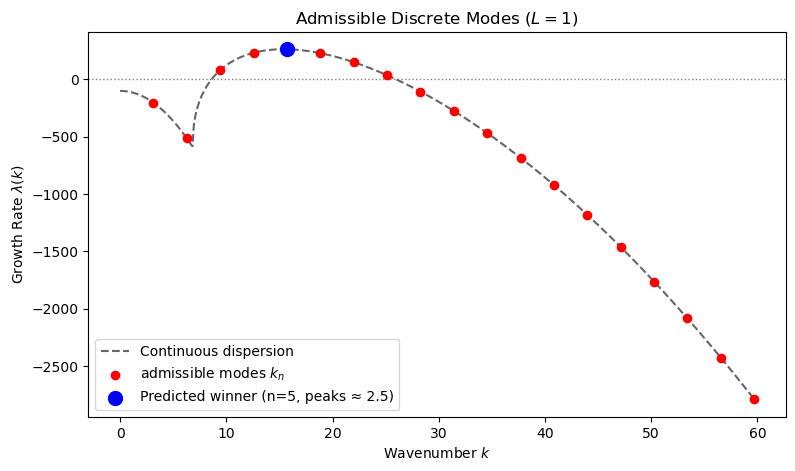

In [22]:
winning_idx = np.argmax(lam_n)
winning_n = n[winning_idx]
winning_k = k_n[winning_idx]
winning_lam = lam_n[winning_idx]

k_dense = np.linspace(0, max(k_n), 500)
lam_dense = np.array(
    [
        growth_analytical(k_val, gamma=1000, u=u_star, v=v_star, D=20)
        for k_val in k_dense
    ]
)

plt.figure(figsize=(9, 5))
plt.plot(k_dense, lam_dense, "k--", alpha=0.6, label="Continuous dispersion")
plt.scatter(k_n, lam_n, zorder = 3, c='red', label=rf'admissible modes $k_n$')
plt.scatter(
    [winning_k],
    [winning_lam],
    color="blue",
    s=100,
    zorder=3,
    label=f"Predicted winner (n={winning_n}, peaks ≈ {winning_n/2:.1f})",
)

plt.axhline(0, color="gray", linestyle=":", linewidth=1)
plt.xlabel("Wavenumber $k$")
plt.ylabel("Growth Rate $\\lambda(k)$")
plt.title(
    f"Admissible Discrete Modes ($L={L}$)"
)
plt.legend()
plt.show()

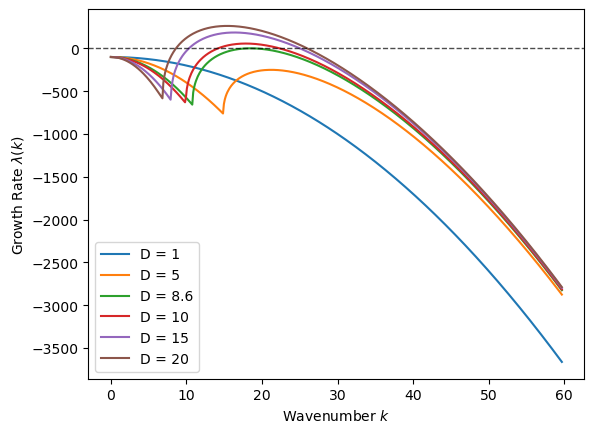

In [23]:
for d in [1,5, 8.6, 10,15,20]:
    k_dense_ds = np.linspace(0, max(k_n), 500)
    lam_dense_ds = np.array(
        [
            growth_numerical(k_val, gamma=gamma, u=u_star, v=v_star, D=d) for k_val in k_dense_ds
        ]
    )
    plt.plot(k_dense_ds, lam_dense_ds, label= rf'D = {d}')
plt.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
plt.xlabel("Wavenumber $k$")
plt.ylabel("Growth Rate $\\lambda(k)$")
plt.legend()
plt.show()